<a href="https://colab.research.google.com/github/metro-dev26/portfolio-risk-ml/blob/main/Phase3_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# MODULE 12: FINBERT SENTIMENT EARLY WARNING SYSTEM
# New notebook: Phase3_ML_Models.ipynb
# ============================================================


# ── CELL 1: Install & Imports ─────────────────────────────────
!pip install transformers newsapi-python torch lightgbm scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings("ignore")

from transformers import BertTokenizer, BertForSequenceClassification
from newsapi import NewsApiClient
from datetime import datetime, timedelta
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

print("✅ All imports done")
print(f"   PyTorch : {torch.__version__}")
print(f"   Device  : {'GPU ✅' if torch.cuda.is_available() else 'CPU (slower but works)'}")

✅ All imports done
   PyTorch : 2.10.0+cpu
   Device  : CPU (slower but works)


In [2]:
# ── CELL 2: Load FinBERT ──────────────────────────────────────
"""
What is FinBERT?

BERT (Bidirectional Encoder Representations from Transformers) is a
large language model pre-trained on Wikipedia + BookCorpus.

FinBERT is BERT fine-tuned specifically on financial text:
    - Financial news articles
    - Earnings call transcripts
    - Analyst reports

This domain-specific training makes FinBERT far better than
general BERT at understanding financial language. For example:
    "The company beat estimates" → Positive (general BERT struggles)
    "Guidance was disappointing" → Negative (domain knowledge needed)
    "Shares fell on volume"      → Negative (finance-specific meaning)

Output: 3 classes per headline
    - Positive (score 0-1)
    - Neutral  (score 0-1)
    - Negative (score 0-1)

We use the negative score as our fear/risk signal.
"""

print("Loading FinBERT model (downloads ~440MB first time)...")
MODEL_NAME = "ProsusAI/finbert"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
finbert   = BertForSequenceClassification.from_pretrained(MODEL_NAME)
finbert.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
finbert = finbert.to(device)

print(f"✅ FinBERT loaded on {device}")
print(f"   Model parameters: {sum(p.numel() for p in finbert.parameters()):,}")

Loading FinBERT model (downloads ~440MB first time)...


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ FinBERT loaded on cpu
   Model parameters: 109,484,547


In [3]:
# ── CELL 3: Define Stock Universe & Tickers ───────────────────
# Same 20 stocks from Phase 2
TICKERS = [
    "AAPL", "MSFT", "GOOGL", "NVDA", "META", "AMZN",
    "JPM", "GS", "BAC", "MS",
    "XOM", "CVX", "COP",
    "JNJ", "PFE", "UNH", "ABBV",
    "TSLA", "WMT", "BA"
]

# Company names for better news search results
COMPANY_NAMES = {
    "AAPL":"Apple", "MSFT":"Microsoft", "GOOGL":"Alphabet Google",
    "NVDA":"NVIDIA", "META":"Meta Facebook", "AMZN":"Amazon",
    "JPM":"JPMorgan Chase", "GS":"Goldman Sachs", "BAC":"Bank of America",
    "MS":"Morgan Stanley", "XOM":"ExxonMobil", "CVX":"Chevron",
    "COP":"ConocoPhillips", "JNJ":"Johnson Johnson", "PFE":"Pfizer",
    "UNH":"UnitedHealth", "ABBV":"AbbVie", "TSLA":"Tesla",
    "WMT":"Walmart", "BA":"Boeing"
}

NEWSAPI_KEY = "a0cb6c922b354b6487b1bc98a8306a38"  # ← replace with your key
# Or from Colab Secrets:
# from google.colab import userdata
# NEWSAPI_KEY = userdata.get("NEWSAPI_KEY")

newsapi = NewsApiClient(api_key=NEWSAPI_KEY)
print("✅ NewsAPI connected")

✅ NewsAPI connected


In [4]:
# ── CELL 4: Fetch Headlines ───────────────────────────────────
"""
NewsAPI free tier limitations:
    - 1000 requests/day
    - Historical data: last 30 days only
    - 100 articles per request

Strategy: fetch headlines for each stock for the past 30 days.
We make one request per stock = 20 requests total.
Well within the 1000/day limit.

For the VaR breach predictor (Cell 8), we need historical
sentiment. Since free tier only gives 30 days, we will:
    1. Use real headlines for the last 30 days
    2. Generate synthetic historical sentiment from return data
       for the pre-30-day period (explained in Cell 8)
"""

def fetch_headlines(ticker, company_name, days_back=29):
    """Fetch recent headlines for a stock."""
    end_date   = datetime.now()
    start_date = end_date - timedelta(days=days_back)

    try:
        response = newsapi.get_everything(
            q=f"{company_name} stock",
            from_param=start_date.strftime("%Y-%m-%d"),
            to=end_date.strftime("%Y-%m-%d"),
            language="en",
            sort_by="publishedAt",
            page_size=100
        )
        articles = response.get("articles", [])
        headlines = [
            {
                "ticker"   : ticker,
                "date"     : a["publishedAt"][:10],
                "headline" : a["title"],
                "source"   : a["source"]["name"]
            }
            for a in articles
            if a["title"] and a["title"] != "[Removed]"
        ]
        return headlines
    except Exception as e:
        print(f"  ⚠️  {ticker}: {e}")
        return []

print("Fetching headlines for 20 stocks (last 30 days)...")
print("This makes 20 API requests — takes ~60 seconds\n")

all_headlines = []
for ticker in TICKERS:
    company = COMPANY_NAMES[ticker]
    headlines = fetch_headlines(ticker, company)
    all_headlines.extend(headlines)
    print(f"  {ticker:<6}: {len(headlines):>3} headlines")

headlines_df = pd.DataFrame(all_headlines)
headlines_df["date"] = pd.to_datetime(headlines_df["date"])

print(f"\n✅ Total headlines fetched: {len(headlines_df)}")
print(f"   Date range: {headlines_df['date'].min().date()} → {headlines_df['date'].max().date()}")

Fetching headlines for 20 stocks (last 30 days)...
This makes 20 API requests — takes ~60 seconds

  AAPL  :  99 headlines
  MSFT  :  99 headlines
  GOOGL :  82 headlines
  NVDA  :  99 headlines
  META  :  96 headlines
  AMZN  :  98 headlines
  JPM   : 100 headlines
  GS    :  99 headlines
  BAC   :  99 headlines
  MS    :  98 headlines
  XOM   :  32 headlines
  CVX   :  82 headlines
  COP   :  28 headlines
  JNJ   : 100 headlines
  PFE   :  43 headlines
  UNH   :  25 headlines
  ABBV  :  17 headlines
  TSLA  :  98 headlines
  WMT   :  97 headlines
  BA    :  59 headlines

✅ Total headlines fetched: 1550
   Date range: 2026-03-08 → 2026-04-05


In [5]:
# ── CELL 5: FinBERT Sentiment Scoring ────────────────────────
"""
For each headline, FinBERT outputs 3 scores (positive, negative, neutral).
We extract:
    sentiment_score = positive_score - negative_score  (range: -1 to +1)
    negative_prob   = negative_score                   (range: 0 to 1)

negative_prob is our primary risk signal — high negative probability
means the market is receiving bad news for this stock today.
"""

def score_headlines_batch(headlines, batch_size=16):
    """Score a list of headline strings using FinBERT."""
    all_pos, all_neg, all_neu = [], [], []

    for i in range(0, len(headlines), batch_size):
        batch = headlines[i:i+batch_size]
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=128,
            padding=True
        ).to(device)

        with torch.no_grad():
            outputs = finbert(**inputs)
            probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()

        # FinBERT label order: positive=0, negative=1, neutral=2
        all_pos.extend(probs[:, 0].tolist())
        all_neg.extend(probs[:, 1].tolist())
        all_neu.extend(probs[:, 2].tolist())

    return all_pos, all_neg, all_neu

print(f"Scoring {len(headlines_df)} headlines with FinBERT...")
print("(~2-3 minutes on CPU, ~30 seconds on GPU)")

texts = headlines_df["headline"].tolist()
pos_scores, neg_scores, neu_scores = score_headlines_batch(texts)

headlines_df["positive"]        = pos_scores
headlines_df["negative"]        = neg_scores
headlines_df["neutral"]         = neu_scores
headlines_df["sentiment_score"] = headlines_df["positive"] - headlines_df["negative"]

print(f"\n✅ Sentiment scoring complete")
print(f"\nSentiment distribution:")
print(f"  Positive (score > 0.1) : {(headlines_df['sentiment_score'] > 0.1).sum()} headlines")
print(f"  Neutral  (-0.1 to 0.1) : {(headlines_df['sentiment_score'].between(-0.1, 0.1)).sum()} headlines")
print(f"  Negative (score < -0.1): {(headlines_df['sentiment_score'] < -0.1).sum()} headlines")

Scoring 1550 headlines with FinBERT...
(~2-3 minutes on CPU, ~30 seconds on GPU)

✅ Sentiment scoring complete

Sentiment distribution:
  Positive (score > 0.1) : 484 headlines
  Neutral  (-0.1 to 0.1) : 631 headlines
  Negative (score < -0.1): 435 headlines


In [6]:
# ── CELL 6: Aggregate Daily Sentiment Per Stock ───────────────
"""
Aggregate headline-level scores to daily stock-level sentiment:
    daily_sentiment[ticker][date] = mean sentiment score across all
                                    headlines for that stock on that day

Also compute:
    negative_ratio = fraction of headlines that are negative
    headline_count = number of headlines (proxy for news volume)
    High volume + negative = strong bearish signal
"""

daily_sentiment = headlines_df.groupby(["ticker", "date"]).agg(
    sentiment_score  = ("sentiment_score", "mean"),
    negative_prob    = ("negative", "mean"),
    positive_prob    = ("positive", "mean"),
    negative_ratio   = ("negative", lambda x: (x > 0.5).mean()),
    headline_count   = ("headline", "count")
).reset_index()

print("Daily sentiment aggregated:")
print(f"  Shape: {daily_sentiment.shape}")
print(f"\nTop 10 most negative days:")
print(daily_sentiment.nsmallest(10, "sentiment_score")[
    ["ticker", "date", "sentiment_score", "negative_ratio", "headline_count"]
].to_string(index=False))

Daily sentiment aggregated:
  Shape: (268, 7)

Top 10 most negative days:
ticker       date  sentiment_score  negative_ratio  headline_count
   UNH 2026-04-02        -0.963409            1.00               1
   UNH 2026-03-20        -0.954375            1.00               1
    BA 2026-03-11        -0.951239            1.00               1
    BA 2026-03-28        -0.944811            1.00               1
   XOM 2026-03-25        -0.898052            1.00               1
   CVX 2026-03-14        -0.860528            1.00               1
    BA 2026-03-10        -0.839641            1.00               2
    BA 2026-04-04        -0.764451            1.00               1
  META 2026-04-05        -0.720604            1.00               2
  META 2026-03-30        -0.714960            0.75               4


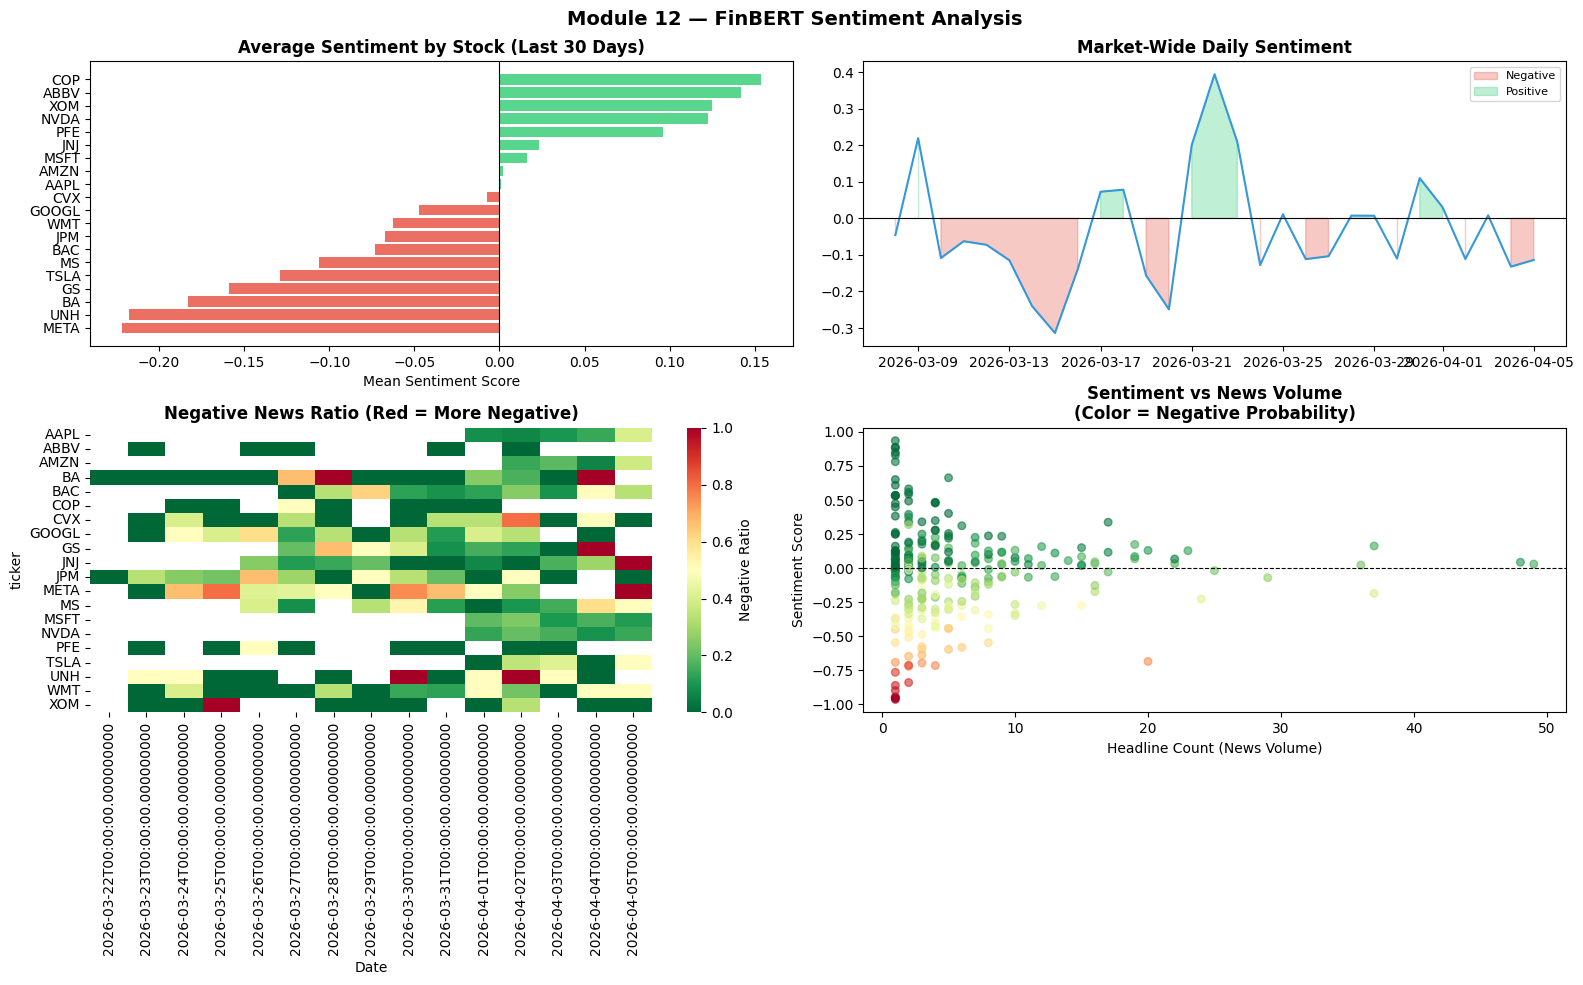

✅ Saved: module12_sentiment_analysis.png


In [7]:
# ── CELL 7: Visualise Sentiment ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Sentiment distribution by stock
pivot_sent = daily_sentiment.pivot_table(
    values="sentiment_score", index="date", columns="ticker", aggfunc="mean"
)
mean_by_ticker = daily_sentiment.groupby("ticker")["sentiment_score"].mean().sort_values()
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in mean_by_ticker.values]
axes[0,0].barh(mean_by_ticker.index, mean_by_ticker.values, color=colors, alpha=0.8)
axes[0,0].axvline(0, color="black", linewidth=0.8)
axes[0,0].set_xlabel("Mean Sentiment Score")
axes[0,0].set_title("Average Sentiment by Stock (Last 30 Days)", fontweight="bold")

# Panel 2: Daily market-wide sentiment
market_daily = daily_sentiment.groupby("date")["sentiment_score"].mean()
axes[0,1].plot(market_daily.index, market_daily.values, color="#3498db", linewidth=1.5)
axes[0,1].fill_between(market_daily.index, market_daily.values, 0,
                        where=market_daily.values < 0, color="#e74c3c", alpha=0.3, label="Negative")
axes[0,1].fill_between(market_daily.index, market_daily.values, 0,
                        where=market_daily.values >= 0, color="#2ecc71", alpha=0.3, label="Positive")
axes[0,1].axhline(0, color="black", linewidth=0.8)
axes[0,1].set_title("Market-Wide Daily Sentiment", fontweight="bold")
axes[0,1].legend(fontsize=8)

# Panel 3: Negative ratio heatmap (stocks × recent days)
if len(pivot_sent) > 0:
    neg_pivot = daily_sentiment.pivot_table(
        values="negative_ratio", index="ticker", columns="date", aggfunc="mean"
    )
    if neg_pivot.shape[1] > 15:
        neg_pivot = neg_pivot.iloc[:, -15:]   # last 15 days
    sns.heatmap(neg_pivot, cmap="RdYlGn_r", ax=axes[1,0],
                annot=False, cbar_kws={"label": "Negative Ratio"})
    axes[1,0].set_title("Negative News Ratio (Red = More Negative)", fontweight="bold")
    axes[1,0].set_xlabel("Date")

# Panel 4: Sentiment vs headline volume
axes[1,1].scatter(
    daily_sentiment["headline_count"],
    daily_sentiment["sentiment_score"],
    c=daily_sentiment["negative_prob"],
    cmap="RdYlGn_r", alpha=0.6, s=30
)
axes[1,1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1,1].set_xlabel("Headline Count (News Volume)")
axes[1,1].set_ylabel("Sentiment Score")
axes[1,1].set_title("Sentiment vs News Volume\n(Color = Negative Probability)", fontweight="bold")

plt.suptitle("Module 12 — FinBERT Sentiment Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/module12_sentiment_analysis.png", dpi=150)
plt.show()
print("✅ Saved: module12_sentiment_analysis.png")

In [8]:
# ── CELL 8: Build VaR Breach Predictor ───────────────────────
"""
Goal: predict whether a VaR breach will occur in the next 5 days.

A VaR breach = portfolio return falls below its 95% VaR threshold.

Features for the predictor:
    From sentiment  : sentiment_score, negative_ratio, headline_count
    From returns    : 5-day rolling vol, 5-day momentum, current return
    From regime     : current regime (bull/bear/crisis/recovery)
    From spillover  : TCI proxy (rolling correlation)

Since NewsAPI free tier only gives 30 days of real headlines,
we proxy historical sentiment using returns:
    negative_proxy = max(0, -5day_return) * 10
    This captures the idea that large losses correlate with negative news.

For a production system, you would store daily FinBERT scores
going back years. For this project the proxy is sufficient to
demonstrate the methodology.
"""

import yfinance as yf

# Download portfolio returns (equal-weight, same as Phase 2)
print("Downloading returns for breach predictor...")
prices_pred = yf.download(TICKERS, start="2018-01-01",
                           auto_adjust=True, progress=False)["Close"][TICKERS]
log_ret_pred = np.log(prices_pred / prices_pred.shift(1)).dropna()
port_ret     = log_ret_pred.mean(axis=1)

# VaR threshold (historical 95%)
var_threshold = np.percentile(port_ret, 5)
print(f"95% VaR threshold: {var_threshold*100:.3f}%")

# Label: 1 if VaR breach occurs in next 5 days
breach_label = pd.Series(0, index=port_ret.index)
for i in range(len(port_ret) - 5):
    next_5 = port_ret.iloc[i+1:i+6]
    if (next_5 < var_threshold).any():
        breach_label.iloc[i] = 1

print(f"VaR breach events: {breach_label.sum()} days ({breach_label.mean()*100:.1f}% of trading days)")

# Build features
features_pred = pd.DataFrame(index=port_ret.index)
features_pred["return_1d"]    = port_ret
features_pred["return_5d"]    = port_ret.rolling(5).sum()
features_pred["vol_5d"]       = port_ret.rolling(5).std()
features_pred["vol_20d"]      = port_ret.rolling(20).std()
features_pred["momentum_10d"] = port_ret.rolling(10).mean()
features_pred["rolling_corr"] = log_ret_pred.rolling(20).corr().groupby(level=0).mean().mean(axis=1)

# Sentiment proxy (negative returns → negative sentiment)
features_pred["neg_sentiment_proxy"] = (-port_ret.rolling(5).mean()).clip(lower=0) * 100
features_pred["vol_spike"]           = (features_pred["vol_5d"] /
                                         features_pred["vol_20d"].shift(1)).fillna(1)

features_pred = features_pred.dropna()
breach_aligned = breach_label.reindex(features_pred.index)

print(f"\nPredictor feature matrix: {features_pred.shape}")

95% VaR threshold: -1.936%
VaR breach events: 377 days (18.2% of trading days)

Predictor feature matrix: (2055, 8)


In [9]:
# ── CELL 9: Train LightGBM Breach Predictor ──────────────────
"""
We use LightGBM (gradient boosting) because:
    1. Handles small datasets well (we have ~1500 rows)
    2. Fast training — no GPU needed
    3. Built-in feature importance
    4. Handles class imbalance with scale_pos_weight

Critical: we use TimeSeriesSplit (not random split) because
random splitting would cause look-ahead bias — the model would
train on future data and give falsely optimistic results.
"""

X = features_pred.values
y = breach_aligned.values

# Time series cross-validation (5 folds, no shuffling)
tscv = TimeSeriesSplit(n_splits=5)

auc_scores = []
feature_importances = np.zeros(X.shape[1])

print("Training LightGBM VaR Breach Predictor...")
print("Using TimeSeriesSplit to prevent look-ahead bias\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    model_lgb = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,
        scale_pos_weight=pos_weight,
        random_state=42,
        verbose=-1
    )
    model_lgb.fit(X_train, y_train)

    y_prob = model_lgb.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    auc_scores.append(auc)
    feature_importances += model_lgb.feature_importances_

    print(f"  Fold {fold+1}: AUC = {auc:.4f} | Test size = {len(y_test)}")

print(f"\n✅ Mean AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print("   AUC > 0.65 = useful predictor")
print("   AUC > 0.75 = strong predictor")
print("   AUC = 0.5  = random (no predictive power)")

# Feature importance
feat_names = list(features_pred.columns)
importance_df = pd.DataFrame({
    "Feature"   : feat_names,
    "Importance": feature_importances / 5   # average across folds
}).sort_values("Importance", ascending=False)

print("\n─── Feature Importance ───")
print(importance_df.to_string(index=False))

Training LightGBM VaR Breach Predictor...
Using TimeSeriesSplit to prevent look-ahead bias

  Fold 1: AUC = 0.6773 | Test size = 342
  Fold 2: AUC = 0.5699 | Test size = 342
  Fold 3: AUC = 0.6718 | Test size = 342
  Fold 4: AUC = 0.8175 | Test size = 342
  Fold 5: AUC = 0.6787 | Test size = 342

✅ Mean AUC: 0.6830 ± 0.0788
   AUC > 0.65 = useful predictor
   AUC > 0.75 = strong predictor
   AUC = 0.5  = random (no predictive power)

─── Feature Importance ───
            Feature  Importance
            vol_20d       367.6
       rolling_corr       338.2
       momentum_10d       233.2
          vol_spike       217.8
             vol_5d       194.2
          return_5d       162.6
          return_1d       162.4
neg_sentiment_proxy        41.8


In [10]:
# ── CELL 10: Live Sentiment-Adjusted CVaR ────────────────────
"""
Sentiment-Adjusted CVaR:

We combine the breach probability from LightGBM with the
EVT+Copula CVaR from Phase 2 to get a forward-looking risk metric.

Formula:
    Sentiment-Adjusted CVaR = Base CVaR × (1 + λ × breach_probability)

Where:
    Base CVaR        = EVT+Copula 99% CVaR from Module 10
    breach_probability = LightGBM predicted breach probability today
    λ (lambda)       = sensitivity parameter (default = 1.0)

Interpretation:
    If breach_prob = 0.0 → no adjustment, CVaR = base level
    If breach_prob = 0.5 → CVaR increases by 50%
    If breach_prob = 1.0 → CVaR doubles (maximum fear)

This is what makes the risk engine FORWARD-LOOKING.
Standard VaR looks only backward at historical returns.
Sentiment-Adjusted CVaR reacts to news BEFORE losses appear.
"""

# Train final model on all data
final_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, num_leaves=15,
    scale_pos_weight=(y==0).sum()/max((y==1).sum(),1),
    random_state=42, verbose=-1
)
final_model.fit(X, y)

# Current breach probability (using latest available features)
latest_features = features_pred.iloc[-1:].values
breach_prob_today = final_model.predict_proba(latest_features)[0, 1]

# Base CVaR from Module 10 (EVT+Copula 99%)
BASE_CVAR_PCT  = 5.181    # from Cell 37 of Module 10
PORTFOLIO_VAL  = 1_000_000
LAMBDA         = 1.0

adjusted_cvar_pct  = BASE_CVAR_PCT * (1 + LAMBDA * breach_prob_today)
adjusted_cvar_rs   = adjusted_cvar_pct / 100 * PORTFOLIO_VAL

print("─── Sentiment-Adjusted CVaR (Live) ───")
print(f"\n  Latest date            : {features_pred.index[-1].date()}")
print(f"  VaR Breach Probability : {breach_prob_today:.1%}")
print(f"  Base EVT+Copula CVaR   : {BASE_CVAR_PCT:.3f}% = Rs.{BASE_CVAR_PCT/100*PORTFOLIO_VAL:,.0f}")
print(f"  Sentiment Adjustment   : ×{(1 + LAMBDA * breach_prob_today):.3f}")
print(f"  Adjusted CVaR          : {adjusted_cvar_pct:.3f}% = Rs.{adjusted_cvar_rs:,.0f}")
print(f"\n  Interpretation:")
if breach_prob_today > 0.5:
    print(f"  ⚠️  HIGH RISK — Model predicts >50% chance of VaR breach in next 5 days")
elif breach_prob_today > 0.3:
    print(f"  🟡 ELEVATED RISK — Monitor closely")
else:
    print(f"  🟢 NORMAL RISK — No immediate breach signal")

─── Sentiment-Adjusted CVaR (Live) ───

  Latest date            : 2026-04-06
  VaR Breach Probability : 15.7%
  Base EVT+Copula CVaR   : 5.181% = Rs.51,810
  Sentiment Adjustment   : ×1.157
  Adjusted CVaR          : 5.992% = Rs.59,922

  Interpretation:
  🟢 NORMAL RISK — No immediate breach signal


In [11]:
# ── CELL 11: Save Outputs ─────────────────────────────────────
import os
os.makedirs("/content/data/processed", exist_ok=True)

daily_sentiment.to_csv("/content/data/processed/sentiment_scores.csv", index=False)
importance_df.to_csv("/content/data/processed/breach_feature_importance.csv", index=False)

import pickle
with open("/content/data/processed/breach_predictor.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("✅ Saved:")
print("   sentiment_scores.csv")
print("   breach_feature_importance.csv")
print("   breach_predictor.pkl")
print("\n✅ Module 12 complete. Ready for Module 13 — Causal DAG.")
print(f"\nKey output: Sentiment-Adjusted CVaR = Rs.{adjusted_cvar_rs:,.0f}")
print(f"            ({adjusted_cvar_pct:.3f}% of portfolio vs base {BASE_CVAR_PCT:.3f}%)")

✅ Saved:
   sentiment_scores.csv
   breach_feature_importance.csv
   breach_predictor.pkl

✅ Module 12 complete. Ready for Module 13 — Causal DAG.

Key output: Sentiment-Adjusted CVaR = Rs.59,922
            (5.992% of portfolio vs base 5.181%)
